Before anything get familiar to terms <br>
A Neuron can contain many possible elements $x_i$ ,corresponding weights $w_i$.<br>
A layer contains many neurons and a Neural network contains many Layers of Neurons.<br>
In a standard layer, every neuron receives the exact same input vector $x$ i.e same $x_i$.                                                                                       
<a href="https://encrypted-tbn1.gstatic.com/images?q=tbn:ANd9GcQAlS83yxBCs8Wkaw04OsMoJheNYRM1BmKXUU6fiQS1-7f9Abpr">NN</a>(Image)

In [1]:
from micrograd.engine import Value
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
%matplotlib inline

In [2]:
# a= -4 in py is just storing the number normally
a = Value(-4.0)
b = Value(2.0)
c = a + b #c=-2
d = a * b + b**3 #d=0
c += c + 1 #c=-3
c += 1 + c + (-a) #c=-1
d += d * 2 + (b + a).relu() # relu if value is negative outs 0 else value remains same.#d=0
d += 3 * d + (b - a).relu() #d=6
e = c - d #e=-7
f = e**2 #f=49
g = f / 2.0 #g=24.5
g += 10.0 / f #g=$$g = 24.5 + (10.0 / 49.0) = 24.5 + 0.20408 = \mathbf{24.7041}$$
print(f'{g.data:.4f}') # prints 24.7041, the outcome of this forward pass
g.backward()
print(f'{a.grad:.4f}') # prints 138.8338, i.e. the numerical value of dg/da
print(f'{b.grad:.4f}') # prints 645.5773, i.e. the numerical value of dg/db

24.7041
138.8338
645.5773


In Micrograd, a = Value(-4.0) wraps that number in a special object that keeps track of two crucial things: \
1..data: The actual numerical value (e.g., -4.0).
2.The Computational Graph: A history of which operations ($+$, $*$, , etc.) and which other Value objects created it. <br>  This hidden "tree" is what allows Micrograd to look backward and calculate derivatives automatically.

## Step 1: The Forward Pass(Math)

All the math steps for which i wrote comments for till math on g

## Step 2: The Back Pass(Backpropagation)

<a href="https://github.com/karpathy/nn-zero-to-hero/blob/master/lectures/micrograd/micrograd_lecture_second_half_roughly.ipynb">Karpathy repo</a><br>
1.<a href="https://www.youtube.com/watch?v=VMj-3S1tku0&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ">The first one</a>

When you call g.backward(), Micrograd automatically calculates the derivative of g with respect to every single variable that helped create it, moving backward through the mathematical chain.

![Backpropagation](back_propagation.png)

In [3]:
x=Value(2)
y=Value(3)
z=x+y
z.backward()
print(f'{x.grad:.2f}')
# just to see and understand quickly

1.00


## The value cell

In [4]:
class Value:
    def __init__(self,data,_children=()): # so called initializer/constructer something like (a,data)
        self.data=data
        self._prev=set(_children)
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        out = Value(self.data+other.data,(self,other))
        return out
    def __mul__(self,other):
        out = Value((self.data)*(other.data),(self,other))
        return out
    def __sub__(self,other):
        out = Value((self.data)-(other.data),(self,other))
        return out
    def __truediv__(self,other): # 5/2 = 2.5 
        out=Value(self.data/(other.data),(self,other))
        return out
    def __mod__(self, other):
        out = Value(self.data%(other.data),(self,other))
        return out
    def __pow__(self, other):
        out = Value(self.data**(other.data),(self,other))
        return out
    def __neg__(self):
        return Value(-self.data)
    def __floordiv__(self, other): # 5/2 = 2
        out = Value(self.data // other.data)
        return out
a=Value(2)
b=Value(4)
c=Value(5)
d=a*b+c
d

Value(data=13)

In [5]:
d._prev

{Value(data=5), Value(data=8)}

In [6]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''): # _op for operations 
    self.data = data
    self.grad = 0.0 
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label # label is for just variable name which help us to visualize while drawing the graph below

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev: #for each variable created there is a parent set visited() stores that parent.  
          build_topo(child) #now we are building topo of parents before the child so the topo has the first created as first element 
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0 # self gradient is 1 
    for node in reversed(topo): # have to reverse topo to because we are using back propagation
      node._backward()


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L.backward()
print(f.grad)

4.0


$$out = self \times other$$

out.grad = self.grad*other + self*other.grad(I wrote this)
That equation you wrote is an incredibly common thing to get tangled up in when learning backpropagation!

What you wrote: `out.grad = self.grad * other + self * other.grad` is actually a variation of the **Multivariable Product Rule** from calculus. However, in the context of an autograd engine, it is incorrect for two very specific reasons.

Let's look at exactly why it's structured differently in code, and how to fix the intuition.

---

### Mistake 1: The Direction of Information Flow

In backpropagation, information moves **backward** (from right to left).

* In your equation, you are trying to calculate `out.grad` using the parents' gradients.
* In reality, **`out.grad` is already known!** It was calculated by whatever operation came *after* `out`.

Our goal in this specific function is to calculate the unknown parent gradients (`self.grad` and `other.grad`) using the known child gradient (`out.grad`).

---

### Mistake 2: Mixing Up "Data" and "Gradients"

Let's look at the mathematical Chain Rule for a multiplication gate.

If the final output of our entire neural network is a value called $L$ (Loss), then:

* `out.grad` means $\frac{\partial L}{\partial out}$
* `self.grad` means $\frac{\partial L}{\partial self}$

According to the Chain Rule, to find $\frac{\partial L}{\partial self}$, we multiply the incoming gradient by the local derivative:

$$\frac{\partial L}{\partial self} = \frac{\partial L}{\partial out} \times \frac{\partial out}{\partial self}$$

We know that $\frac{\partial out}{\partial self} = other.data$. If we substitute that in, we get:

$$\frac{\partial L}{\partial self} = \frac{\partial L}{\partial out} \times other.data$$

Translating this mathematical formula directly into Python code gives us:
`self.grad += out.grad * other.data`

---

### The Correct Way to Write It

Instead of trying to find `out.grad` in one big equation, we use the known `out.grad` to update both parents separately:

This is the absolute trickiest part of building an autograd engine. If you only test your engine on simple, straight-line equations, you can actually use `=` and it will work perfectly.

But the moment your math equation uses the **same variable more than once**, using `=` will break the calculus completely.

We use `+=` because of a rule in calculus called the **Multivariable Chain Rule**, which says: **If a variable branches out to multiple paths in your equation, its total gradient is the sum of the gradients from all of those paths.**

Here is exactly what that means with a clear example.

---

### The Problem: The Variable Reuse Case

Let's look at a simple equation where we square a number by multiplying it by itself:

$$d = a \times a$$

If we use $a = 3$, then $d = 3 \times 3 = 9$.

From basic calculus, we know the derivative of $x^2$ is $2x$. So the gradient of $a$ should be:


$$\frac{\partial d}{\partial a} = 2 \times a = 2 \times 3 = 6$$

Let’s trace how your code evaluates `d = a * a` using `=` versus `+=`.

---

### Scenario A: If we used `=` (The Broken Way)

Inside your `__mul__` method, both `self` and `other` point to the exact same object: `a`.

# HYPOTHETICAL BROKEN CODE
def _backward():
    self.grad = other.data * out.grad   # Step 1
    other.grad = self.data * out.grad  # Step 2

Let's run `d.backward()`. Remember, `out.grad` starts at `1.0`.

1. **Step 1 runs:** It calculates `self.grad = 3 * 1.0`. Since `self` is `a`, **`a.grad` becomes `3**`.
2. **Step 2 runs:** It calculates `other.grad = 3 * 1.0`. Since `other` is *also* `a`, it overwrites the previous value. **`a.grad` gets overwritten with `3**`.

The final result for `a.grad` is `3`. But calculus tells us the answer **must be 6**! The code completely lost half of the gradient because it overwrote it.

---

### Scenario B: If we use `+=` (The Correct Way)

Now let's run it with the accumulating plus-equals sign:

# YOUR CORRECT CODE
def _backward():
    self.grad += other.data * out.grad   # Step 1
    other.grad += self.data * out.grad  # Step 2

Initially, `a.grad = 0.0`.

1. **Step 1 runs:** It calculates `3 * 1.0 = 3`. It adds this to `self.grad` (`a.grad`).

$$a.grad = 0.0 + 3 = 3$$


2. **Step 2 runs:** It calculates `3 * 1.0 = 3`. It adds this to `other.grad` (which is also `a.grad`).

$$a.grad = 3 + 3 = 6$$



By using `+=`, the object accumulates the gradients flowing from **both** sides of the multiplication gate. The final result is `6`, which matches the calculus perfectly!

---

### Real-World Example: Neural Networks

In a real neural network, you reuse variables constantly. For example, a single weight in a neural network layer might be used to calculate the output for 100 different training images in a batch.

If you used `=`, the weight would only remember the gradient from the very last image processed, completely discarding what it learned from the other 99 images. Using `+=` ensures that the weight accumulates the learning signals from the entire network graph!

<br><br>

Let’s look at a complete, concrete example where using `=` instead of `+=` on `self` completely corrupts the math.

We will use the split-path equation from before, because it perfectly exposes the bug:

$$y = x + x$$

$$z = x \times y$$

If $x = 3.0$, let's do the calculus by hand first so we know the absolute truth. If we substitute $y$ into the equation for $z$:


$$z = x \times (x + x) = x \times (2x) = 2x^2$$

The derivative of $2x^2$ with respect to $x$ is $4x$. Since $x = 3.0$:


$$\frac{\partial z}{\partial x} = 4 \times 3.0 = \mathbf{12.0}$$

---

### The Code Setup

Here is the code representing this exact graph. We will trace backpropagation using your mixed rule vs the correct rule.

x = Value(3.0, label='x')
y = x + x;   y.label = 'y'   # Triggered __add__
z = x * y;   z.label = 'z'   # Triggered __mul__

# HYPOTHETICAL BROKEN MULTIPLICATION
def _backward():
    self.grad = other.data * out.grad   # Wipes out previous data with =
    other.grad += self.data * out.grad  # Accumulates with +=

#### Step 1: Process the Multiplication Gate (`z = x * y`)

* **Update `self` (`x`):** 
$$x.grad = 0.0 + (6.0 \times 1.0) = \mathbf{6.0}$$


* **Update `other` (`y`):** 
$$y.grad = 0.0 + (3.0 \times 1.0) = \mathbf{3.0}$$



#### Step 2: Process the Addition Gate (`y = x + x`)

Now we pass `y.grad` (which is `3.0`) backward to `x`.

* **Update `self` (`x`):** 
$$x.grad = 6.0 + (1.0 \times 3.0) = \mathbf{9.0}$$



*(Information preserved! We added the new gradient to the 6.0 we already had).*
* **Update `other` (`x`):** 
$$x.grad = 9.0 + (1.0 \times 3.0) = \mathbf{12.0}$$



**Final calculated `x.grad` = 12.0.**

The math matches perfectly. By making sure *every single assignment* uses `+=`, we treat gradients like a collection stream—no matter how many times a variable splits or loops through a complex neural network, its total impact is safely accumulated without ever overwriting its history.

In [57]:
import math
import random

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"
  
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
    
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
    
        return out

    def __radd__(self, other): # Handles: float + Value
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
    
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
      
        return out

    def __rmul__(self, other): # Handles: float * Value
        return self * other
  
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
    
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
    
        return out

    def __sub__(self, other): # Handles: Value - float/Value
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data - other.data, (self, other), '-')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += -1.0 * out.grad
        out._backward = _backward

        return out

    def __rsub__(self, other): # Handles: float - Value
        other = other if isinstance(other, Value) else Value(other)
        out = Value(other.data - self.data, (other, self), '-')

        def _backward():
            other.grad += 1.0 * out.grad
            self.grad += -1.0 * out.grad
        out._backward = _backward

        return out
    
    def __pow__(self, other): # Handles: Value ** float/int
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            # Power rule: d/dx (x^n) = n * x^(n-1)
            self.grad += (other * (self.data ** (other - 1))) * out.grad
        out._backward = _backward

        return out
  
    def backward(self):
        topo = []
        visited = set()
        
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        
        build_topo(self)
    
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0, grad=0.0)

<br><br>

In [8]:
import numpy as np
from graphviz import Digraph

def trace(root_input):
    # Builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    
    def build(v):
        if v not in nodes:
            nodes.add(v)
            # Ensure the node has the micrograd attributes before traversing
            if hasattr(v, '_prev'):
                for child in v._prev:
                    edges.add((child, v))
                    build(child)
                    
    # --- Modification: Handle single Value, lists, or numpy arrays ---
    if isinstance(root_input, (list, tuple)):
        roots = root_input
    elif isinstance(root_input, np.ndarray):
        roots = root_input.flatten() # Flatten to safely iterate over multi-dimensional arrays
    else:
        roots = [root_input] # Wrap single Value node in a list
        
    for root in roots:
        build(root)
        
    return nodes, edges

def draw_dot(root_input):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    # Trace handles single items or collections now
    nodes, edges = trace(root_input)
    
    for n in nodes:
        uid = str(id(n))
        # Safely get label if it doesn't exist
        label_str = getattr(n, 'label', '') or ''
        
        # Create a rectangular ('record') node for the Value
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (label_str, n.data, n.grad), shape='record')
        
        if hasattr(n, '_op') and n._op:
            # If this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # And connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # Connect n1 to the op node of n2
        if hasattr(n2, '_op') and n2._op:
            dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        else:
            dot.edge(str(id(n1)), str(id(n2)))

    return dot

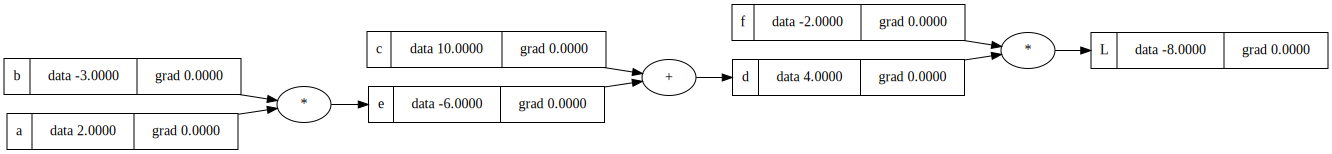

In [9]:
draw_dot(L)

In [10]:
a.data += 0.01*a.grad
b.data += 0.01*b.grad
c.data += 0.01*c.grad
f.data += 0.01*f.grad

e = a*b; 
d = e + c; 
L = d * f; 
print(L.data)

-8.0


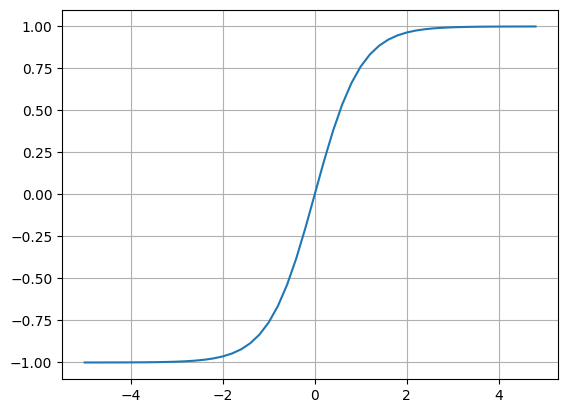

In [11]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2)))
plt.grid()
plt.xticks()
plt.show()

In [12]:
## Back Propagation

<img src="https://cs231n.github.io/assets/nn1/neuron_model.jpeg">

use the above image for visualization

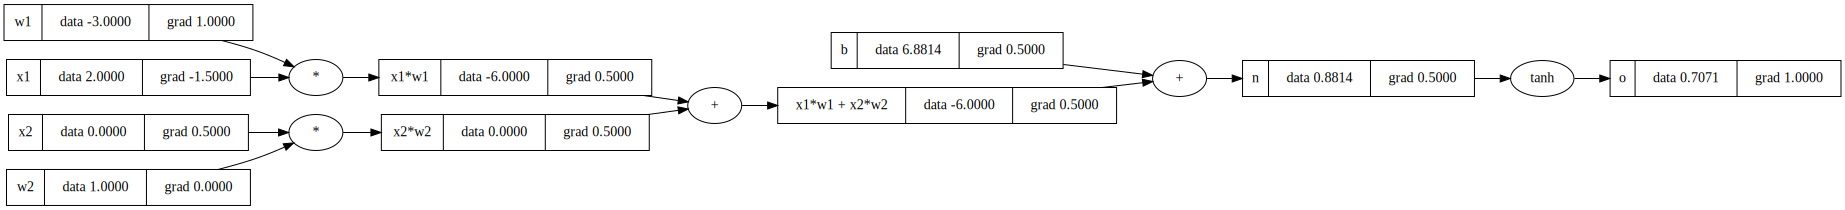

In [13]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n' # this is the cell body in the  above diagram
o = n.tanh(); o.label = 'o' # this is the activation function f in the above diagram
o.backward()
draw_dot(o)

## increasing the result by increasing the weights.
* the gradient is simply derivative ( treat like this for understanding) if we increase the value in the direction of gradient to result in increase the final variable <br>
* here it is a simpler model we have only one final node (the intution video has 10 final nodes "as 10 digits".)<br>
* I mean single layer.

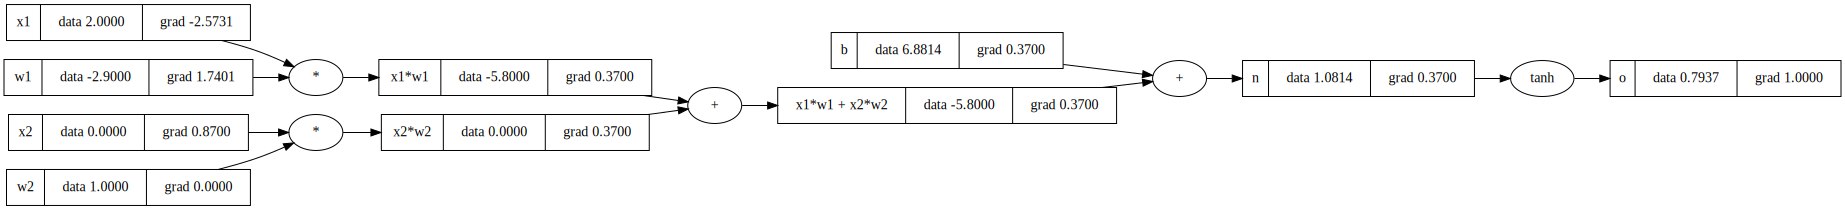

In [14]:
w1.data += 0.1*w1.grad
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n' # this is the cell body in the  above diagram
o = n.tanh(); o.label = 'o' # this is the activation function f in the above diagram
o.backward()
draw_dot(o)

I'm re running the cell above the upper one just to make sure in understanding the difference

Increasing the bias
(i think it was direct so not showing here)

Increasing the Inputs(xi)

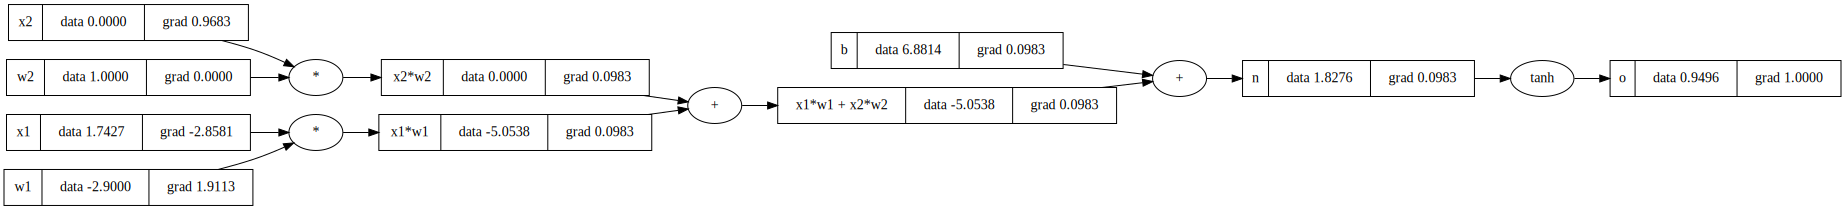

In [15]:
x1.data += 0.1*x1.grad
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n' # this is the cell body in the  above diagram
o = n.tanh(); o.label = 'o' # this is the activation function f in the above diagram
o.backward()
draw_dot(o)

Here we can observe that the grad of x1 is negative but i moved x1 in the opposite direction of grad so the final output value of "o" is decreased

# Pytorch

Before going micrograd is a subcase of pytorch ( when all the elements are single scalar not a array)

<a href="https://docs.pytorch.org/tutorials/beginner/blitz/tensor_tutorial.html">Pytorch documentation</a>

In [16]:
z=torch.Tensor(np.array([2,3,4,5])).double()
y = int(z.data[0])
print(y)
z

2


tensor([2., 3., 4., 5.], dtype=torch.float64)

In [17]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True #pytorch didn't calculate grad for leaf node. so we have to make it true
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True #pytorch cast the variable to float 32 but we are doing double() to float 64
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item()) # In micrograd we built .data() to get value here we do .item() for each thing to get their value.
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSEi1tlkc_X3o6lXjVV0_FxfIOTdlQpnh_gtg&s" alt="Image of multilayer nn for refernce">
Image for refernce 

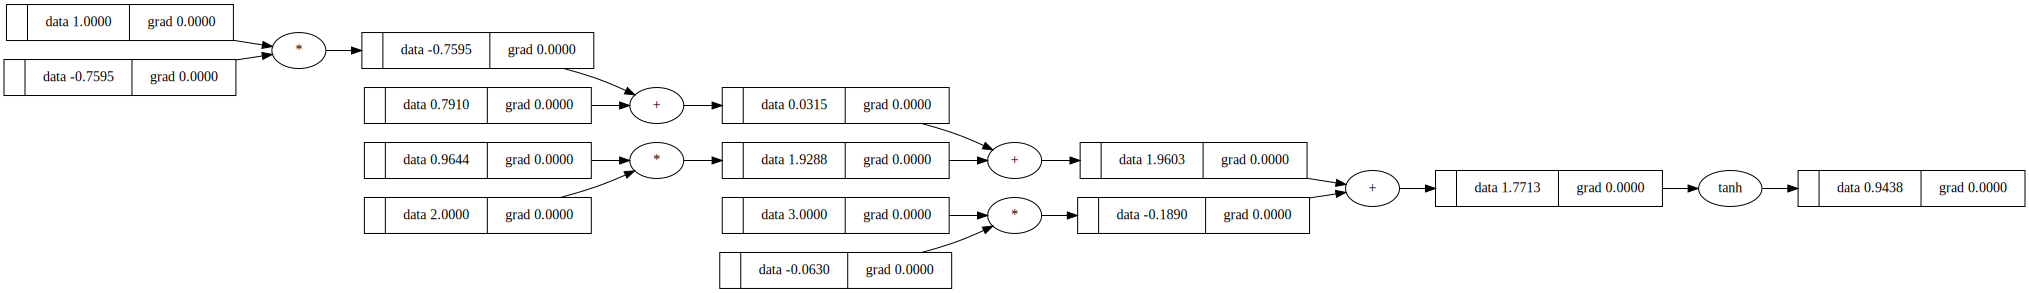

In [18]:
# A single Neuron
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)] # this is creating the weights nin number of times
        self.b = Value(random.uniform(-1,1))
    def __call__(self,x):
        # w * x + b #print(list(zip(self.w,x)))
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
# usage
x=[1,2,3]
n=Neuron(3)
n(x)
draw_dot(n(x))

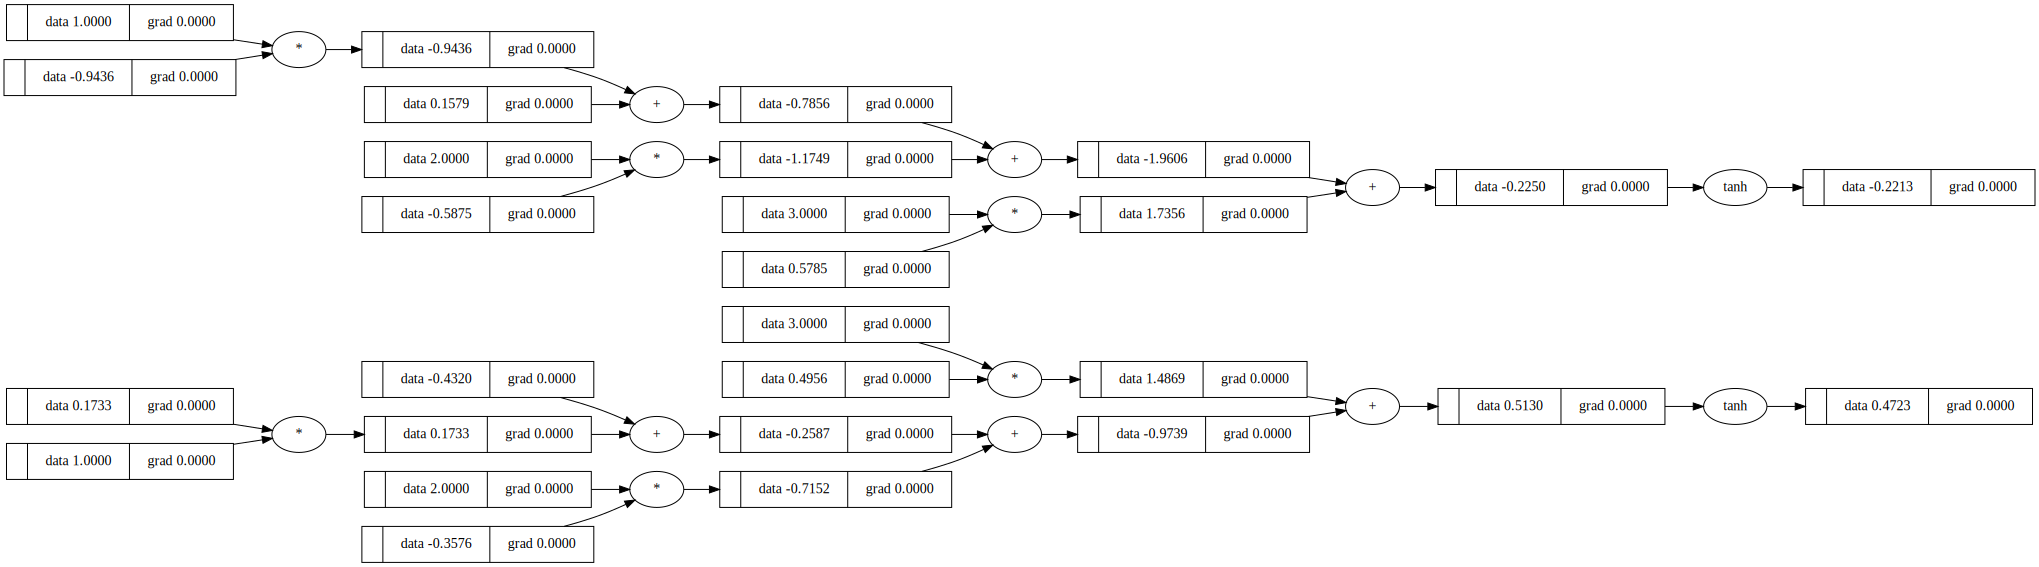

In [19]:
# A single layer
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    def __call__(self,x):
        # w * x + b #print(list(zip(self.w,x)))
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
class Layer:
  
  def __init__(self, nin, nout): # nin is the list of number of $x_i$ in the neuron.
    self.neurons = [Neuron(nin) for _ in range(nout)] # nout is number of neurons in a layer
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
# usage
x=[1,2,3]
n=Layer(3,2)
n(x)
draw_dot(n(x))

In [46]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    def __call__(self,x):
        # w * x + b #print(list(zip(self.w,x)))
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

x=[2.0,3.0,-1.0]
n=MLP(3,[4,4,1])
n(x)

Value(data=0.35112971464993453)

An **MLP** stands for **Multi-Layer Perceptron**. In plain English, it is a fully connected neural network.

Now that you have individual `Neurons` grouped into `Layers`, the `MLP` class is the final wrapper that stacks those layers on top of each other to build a complete, deep neural network.

Let's break down exactly how your code constructs and runs this network.

---

## 1. Building the Network (`__init__`)

def __init__(self, nin, nouts): <br>
    sz = [nin] + nouts <br>
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

<br>
When you instantiate your network with `n = MLP(3, [4, 4, 1])`, here is what happens step-by-step:

### Step A: Defining the Sizes (`sz`)

The code combines your single input size `nin` (3) with your list of layer outputs `nouts` `[4, 4, 1]`.

* `sz = [3] + [4, 4, 1]` which creates the list: `[3, 4, 4, 1]`

This list represents the complete blueprint of your network's architecture:

* **3** inputs
* **4** neurons in the first hidden layer
* **4** neurons in the second hidden layer
* **1** neuron in the final output layer

### Step B: Stacking the Layers

The list comprehension loops through this architecture blueprint to create the `Layer` objects:

* **Layer 1:** `Layer(sz[0], sz[1])` $\rightarrow$ `Layer(3, 4)`. Takes 3 inputs, has 4 neurons.
* **Layer 2:** `Layer(sz[1], sz[2])` $\rightarrow$ `Layer(4, 4)`. Takes 4 inputs, has 4 neurons.
* **Layer 3:** `Layer(sz[2], sz[3])` $\rightarrow$ `Layer(4, 1)`. Takes 4 inputs, has 1 neuron.

All three layer objects are stored sequentially in the `self.layers` list.

---

## 2. Running the Data Forward (`__call__`)

def __call__(self, x):<br>
    for layer in self.layers:<br>
        x = layer(x)<br>
    return x<br>

This is the **forward pass**. When you call `n(x)` with your inputs `x = [2.0, 3.0, -1.0]`, the data flows through the layers like a relay race:

1. **Input:** You feed the initial list of 3 numbers (`x`) into the loop.
2. **Layer 1:** Processes the 3 numbers and outputs **4 new numbers**. The variable `x` is overwritten with these 4 numbers.
3. **Layer 2:** Processes those 4 numbers and outputs **4 different numbers**. The variable `x` is overwritten again.
4. **Layer 3:** Processes those 4 numbers and outputs **1 final number** (wrapped in a `Value` object).
5. **Output:** The final single value is returned.

---

## Summary of your specific network

By running `n = MLP(3, [4, 4, 1])`, you have built a network that contains a total of **9 neurons** ($4 + 4 + 1$) distributed across 3 layers.

Because each layer passes its outputs to become the inputs of the next layer, the network can learn incredibly complex relationships between your initial 3 raw inputs and your final prediction.

<br>

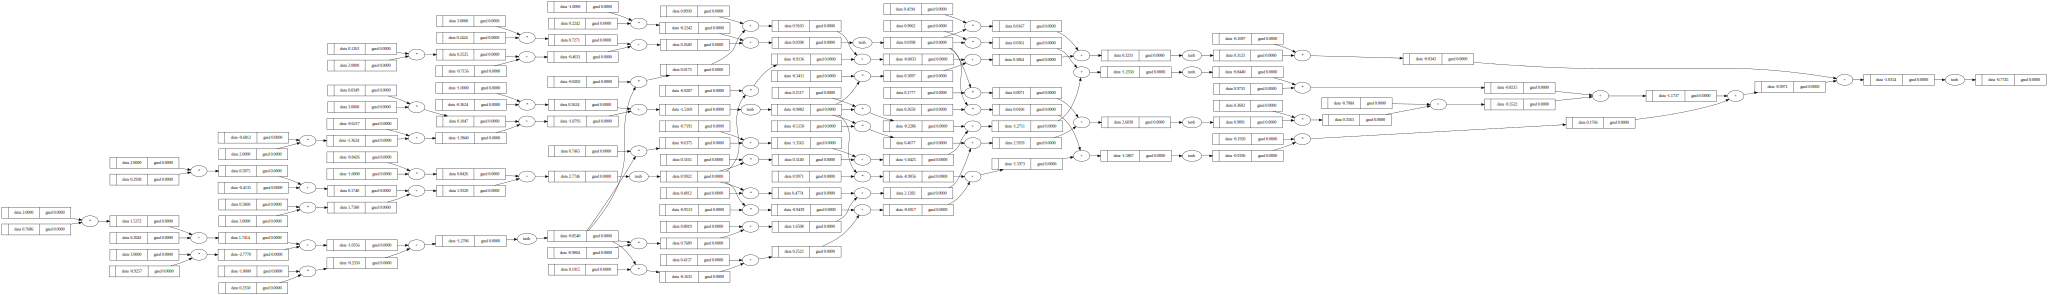

In [27]:
draw_dot(n(x))

##The Target's Role in Training (The Feedback Loop)<br>The target is the foundational piece of Supervised Learning. Without it, the network cannot learn because it won't know if its predictions are good or bad.<br>Here is how the target is used during training:<br>Forward Pass: You give the network an input (e.g., an image of a cat). The network predicts: "This is a dog." ($\hat{y}$)<br>Loss Calculation: The network looks at the target (which says: "This is actually a cat" ($y$)). It uses a Loss Function to calculate mathematically how far off its guess was.<br>Backpropagation: The network uses that loss value to tweak its internal weights and biases so that next time, its prediction will be closer to the target.

In [63]:
n=MLP(3,[4,4,1])
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs] # this is using the previous NN definition i.e 4,4,1 
ypred

[Value(data=0.943922781759988, grad=0.0),
 Value(data=0.9898593368240197, grad=0.0),
 Value(data=0.7591566340563806, grad=0.0),
 Value(data=0.943033378701194, grad=0.0)]

In [69]:
[(yout-ygt)**2 for yout,ygt in zip(ypred,ys)]
#loss is sum of above
loss = sum([(yout-ygt)**2 for yout,ygt in zip(ypred,ys)])
# we have to minimize loss so every prediction is near to it's targets.
loss

Value(data=7.060562093838043, grad=0.0)

In [70]:
loss.backward()

In [80]:
# n is MLP. MLP has layers as their inbuilt function (note Layer is a class),layers are of class Layer which has inbuilt function neurons(which are elements of class Neuron) which as induilt functions as w,b 
n.layers[0].neurons[0].w[1].grad

-0.5147177668061156

In [114]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    def __call__(self,x):
        # w * x + b #print(list(zip(self.w,x)))
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    def parameters(self):
        return self.w + [self.b]
class Layer:
  
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
  
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params

class MLP:
  
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

x=[2.0,3.0]
#n=Neuron(3)
#n(x)
#print(n.parameters())
#m=Layer(2,4)
#m(x)

#print(m.parameters())

In [115]:
x = [2.0,3.0,-1.0]
n=MLP(3,[4,4,1])
n(x)

Value(data=0.6923316674655677, grad=0.0)

In [116]:
n.parameters()

[Value(data=-0.10119731210479088, grad=0.0),
 Value(data=0.022806295800142484, grad=0.0),
 Value(data=-0.028518925603360223, grad=0.0),
 Value(data=0.4899218212286576, grad=0.0),
 Value(data=0.9108224191456828, grad=0.0),
 Value(data=-0.7827145444178234, grad=0.0),
 Value(data=-0.17281044339253104, grad=0.0),
 Value(data=-0.23084849378106975, grad=0.0),
 Value(data=0.2956184948520615, grad=0.0),
 Value(data=-0.5053046460557211, grad=0.0),
 Value(data=0.39221922734670756, grad=0.0),
 Value(data=-0.7868710548041302, grad=0.0),
 Value(data=-0.010356660538587859, grad=0.0),
 Value(data=-0.580508443170918, grad=0.0),
 Value(data=0.34078832313023266, grad=0.0),
 Value(data=0.8209659001619514, grad=0.0),
 Value(data=0.18274749921012812, grad=0.0),
 Value(data=0.2977038682132833, grad=0.0),
 Value(data=0.10738174378654208, grad=0.0),
 Value(data=0.29423540237669665, grad=0.0),
 Value(data=-0.6749290611481165, grad=0.0),
 Value(data=-0.7789056291844585, grad=0.0),
 Value(data=-0.807451258288767

In [117]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs] # this is using the previous NN definition i.e 4,4,1 
ypred

[Value(data=0.6923316674655677, grad=0.0),
 Value(data=-0.8072347090076888, grad=0.0),
 Value(data=0.4813836102320417, grad=0.0),
 Value(data=0.5382995866201598, grad=0.0)]

In [172]:
ypred = [n(x) for x in xs]
#loss is sum of above
loss = sum([(yout-ygt)**2 for yout,ygt in zip(ypred,ys)])
# we have to minimize loss so every prediction is near to it's targets.
loss

Value(data=1.6823049275932456, grad=0.0)

In [152]:
loss.backward()

In [153]:
n.parameters()

[Value(data=-0.03882422493062638, grad=-6.831788943378353),
 Value(data=0.12558243128719557, grad=-11.234790204956147),
 Value(data=-0.010161373460212963, grad=-1.717504450360138),
 Value(data=0.5507182560250646, grad=-6.629792196405284),
 Value(data=0.9235728465883333, grad=-1.4473943559128721),
 Value(data=-0.74064870379507, grad=-4.640582415306385),
 Value(data=-0.10799298141679389, grad=-6.892452480073962),
 Value(data=-0.19906603889305896, grad=-3.4090883964135257),
 Value(data=0.3124967398571696, grad=-1.7804509207419228),
 Value(data=-0.502968034413926, grad=-0.3310209041495253),
 Value(data=0.3962028179630584, grad=-0.3432596495842519),
 Value(data=-0.7779586913251044, grad=-0.966180192798541),
 Value(data=-0.020978884385882152, grad=1.9805655290124469),
 Value(data=-0.5665661988845757, grad=-0.5993615475014732),
 Value(data=0.45175006687671176, grad=-12.668302876301897),
 Value(data=0.8483667177481246, grad=-2.152287765336742),
 Value(data=0.1567269546976211, grad=2.5711802297

In [122]:
n.layers[0].neurons[0].w[0].grad

-6.23730871741645

In [128]:
n.layers[0].neurons[0].w[0].data

-0.10119731210479088

In [129]:
for p in n.parameters():
    p.data += -(0.01*p.grad) 

In [130]:
n.layers[0].neurons[0].w[0].grad

-6.23730871741645

In [131]:
n.layers[0].neurons[0].w[0].data

-0.03882422493062638

In [150]:
[(yout-ygt)**2 for yout,ygt in zip(ypred,ys)]
#loss is sum of above
loss = sum([(yout-ygt)**2 for yout,ygt in zip(ypred,ys)])
# we have to minimize loss so every prediction is near to it's targets.
loss

Value(data=2.539482932635101, grad=0.0)

In [179]:
# since i changed the weights and biases i have to again run backward pass to get the updated gradient
n.parameters()

[Value(data=-0.03882422493062638, grad=-0.5944802259619022),
 Value(data=0.12558243128719557, grad=-0.9571766562508375),
 Value(data=-0.010161373460212963, grad=0.11825076395458797),
 Value(data=0.5507182560250646, grad=-0.5501487167645759),
 Value(data=0.9235728465883333, grad=-0.17235161164783336),
 Value(data=-0.74064870379507, grad=-0.4339983530310385),
 Value(data=-0.10799298141679389, grad=-0.4107062825002477),
 Value(data=-0.19906603889305896, grad=-0.23084290761244608),
 Value(data=0.3124967398571696, grad=-0.09262642023111209),
 Value(data=-0.502968034413926, grad=-0.09735973997001475),
 Value(data=0.3962028179630584, grad=0.055099412050833414),
 Value(data=-0.7779586913251044, grad=-0.07494384489595625),
 Value(data=-0.020978884385882152, grad=0.9183431442830172),
 Value(data=-0.5665661988845757, grad=0.7948628811327556),
 Value(data=0.45175006687671176, grad=-1.5721285016539883),
 Value(data=0.8483667177481246, grad=0.587793993280579),
 Value(data=0.1567269546976211, grad=-0

## important before doing backward pass again set the gradient to 0 i.e p.grad=0.0 <br>
otherwise the gradient will += as we built it in such a way

In [174]:
for p in n.parameters():
    p.grad=0.0

In [177]:
loss.backward()

In [178]:
n.parameters()

[Value(data=-0.03882422493062638, grad=-0.5944802259619022),
 Value(data=0.12558243128719557, grad=-0.9571766562508375),
 Value(data=-0.010161373460212963, grad=0.11825076395458797),
 Value(data=0.5507182560250646, grad=-0.5501487167645759),
 Value(data=0.9235728465883333, grad=-0.17235161164783336),
 Value(data=-0.74064870379507, grad=-0.4339983530310385),
 Value(data=-0.10799298141679389, grad=-0.4107062825002477),
 Value(data=-0.19906603889305896, grad=-0.23084290761244608),
 Value(data=0.3124967398571696, grad=-0.09262642023111209),
 Value(data=-0.502968034413926, grad=-0.09735973997001475),
 Value(data=0.3962028179630584, grad=0.055099412050833414),
 Value(data=-0.7779586913251044, grad=-0.07494384489595625),
 Value(data=-0.020978884385882152, grad=0.9183431442830172),
 Value(data=-0.5665661988845757, grad=0.7948628811327556),
 Value(data=0.45175006687671176, grad=-1.5721285016539883),
 Value(data=0.8483667177481246, grad=0.587793993280579),
 Value(data=0.1567269546976211, grad=-0